IMPORT

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

BASE_DIR = Path("..")

CLEANED_DATA_PATH = BASE_DIR / "data" / "processed" / "cleaned_online_retail.csv"
RFM_PATH = BASE_DIR / "data" / "processed" / "rfm_features.csv"

PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"
TABLES_DIR = BASE_DIR / "outputs" / "tables"

LOAD DATASET

In [2]:
df = pd.read_csv(CLEANED_DATA_PATH)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

rfm = pd.read_csv(RFM_PATH)

print(df.shape)
print(rfm.shape)

(392692, 9)
(4338, 4)


SPENDING VOLATILITY

In [3]:
spending = df.groupby("CustomerID").agg(

    Spending_Mean=("TotalPrice","mean"),

    Spending_Std=("TotalPrice","std")

).fillna(0)

spending["Spending_CV"] = (
    spending["Spending_Std"] /
    spending["Spending_Mean"].replace(0,np.nan)
)

spending = spending.fillna(0)

spending.head()

,Spending_Mean,Spending_Std,Spending_CV
CustomerID,,,
12346,77183.600000,0.000000,0.000000
12347,23.681319,23.289902,0.983472
12348,57.975484,48.514857,0.836817
12349,24.076027,34.655913,1.439437
12350,19.670588,7.275538,0.369869


PURCHASE INTERVAL FEATURES

In [4]:
df = df.sort_values(["CustomerID","InvoiceDate"])

df["PurchaseInterval"] = (
    df.groupby("CustomerID")["InvoiceDate"]
    .diff()
    .dt.days
)

interval_features = df.groupby("CustomerID").agg(

    Interval_Mean=("PurchaseInterval","mean"),

    Interval_Std=("PurchaseInterval","std")

).fillna(0)

interval_features["Interval_CV"] = (

    interval_features["Interval_Std"] /

    interval_features["Interval_Mean"].replace(0,np.nan)

)

interval_features = interval_features.fillna(0)

interval_features.head()

,Interval_Mean,Interval_Std,Interval_CV
CustomerID,,,
12346,0.0,0.000000,0.000000
12347,2.0,11.260551,5.630275
12348,9.4,34.088728,3.626460
12349,0.0,0.000000,0.000000
12350,0.0,0.000000,0.000000


BEHAVIOURAL ENTROPY

In [5]:
from scipy.stats import entropy

entropy_values = []

for customer, group in df.groupby("CustomerID"):

    quantity_counts = group["Quantity"].value_counts(normalize=True)

    entropy_values.append([

        customer,

        entropy(quantity_counts)

    ])

entropy_df = pd.DataFrame(

    entropy_values,

    columns=["CustomerID","Behavioural_Entropy"]

)

entropy_df.head()

,CustomerID,Behavioural_Entropy
0,12346,0.000000
1,12347,2.064642
2,12348,2.112679
3,12349,2.049541
4,12350,0.871781


AVG BASKET VALUE

In [6]:
basket = df.groupby("CustomerID").agg(

    Average_Basket_Value=("TotalPrice","mean")

)

basket.head()

,Average_Basket_Value
CustomerID,
12346,77183.600000
12347,23.681319
12348,57.975484
12349,24.076027
12350,19.670588


MERGE ALL FEATURES

In [7]:
rfm_vol = (

    rfm

    .merge(spending,on="CustomerID")

    .merge(interval_features,on="CustomerID")

    .merge(entropy_df,on="CustomerID")

    .merge(basket,on="CustomerID")

)

print(rfm_vol.shape)

rfm_vol.head()

(4338, 12)


,CustomerID,Recency,Frequency,Monetary,Spending_Mean,Spending_Std,Spending_CV,Interval_Mean,Interval_Std,Interval_CV,Behavioural_Entropy,Average_Basket_Value
0,12346,326,1,77183.60,77183.600000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,77183.600000
1,12347,2,7,4310.00,23.681319,23.289902,0.983472,2.0,11.260551,5.630275,2.064642,23.681319
2,12348,75,4,1797.24,57.975484,48.514857,0.836817,9.4,34.088728,3.626460,2.112679,57.975484
3,12349,19,1,1757.55,24.076027,34.655913,1.439437,0.0,0.000000,0.000000,2.049541,24.076027
4,12350,310,1,334.40,19.670588,7.275538,0.369869,0.0,0.000000,0.000000,0.871781,19.670588


FEATURE SUMMARY

In [8]:
summary = rfm_vol.describe().T

summary.to_csv(

    TABLES_DIR /

    "volatility_feature_summary.csv"

)

summary

,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.00000,13813.250000,15299.500000,16778.750000,18287.000000
Recency,4338.0,92.536422,100.014169,1.00000,18.000000,51.000000,142.000000,374.000000
Frequency,4338.0,4.272015,7.697998,1.00000,1.000000,2.000000,5.000000,209.000000
Monetary,4338.0,2048.688081,8985.230220,3.75000,306.482500,668.570000,1660.597500,280206.020000
Spending_Mean,4338.0,68.381590,1467.918294,2.13697,12.393196,17.755000,24.878950,77183.600000
Spending_Std,4338.0,50.684368,1515.892098,0.00000,5.842520,9.567636,19.136937,97265.131753
Spending_CV,4338.0,0.758885,0.470009,0.00000,0.449749,0.699758,0.958997,8.261795
Interval_Mean,4338.0,3.215197,10.790897,0.00000,0.000000,1.066667,2.945603,309.000000
Interval_Std,4338.0,11.291683,15.908007,0.00000,0.000000,6.829212,15.907523,210.155498
Interval_CV,4338.0,3.822572,3.514874,0.00000,0.000000,4.069305,6.284234,20.452104


CORELATION HEATMAP

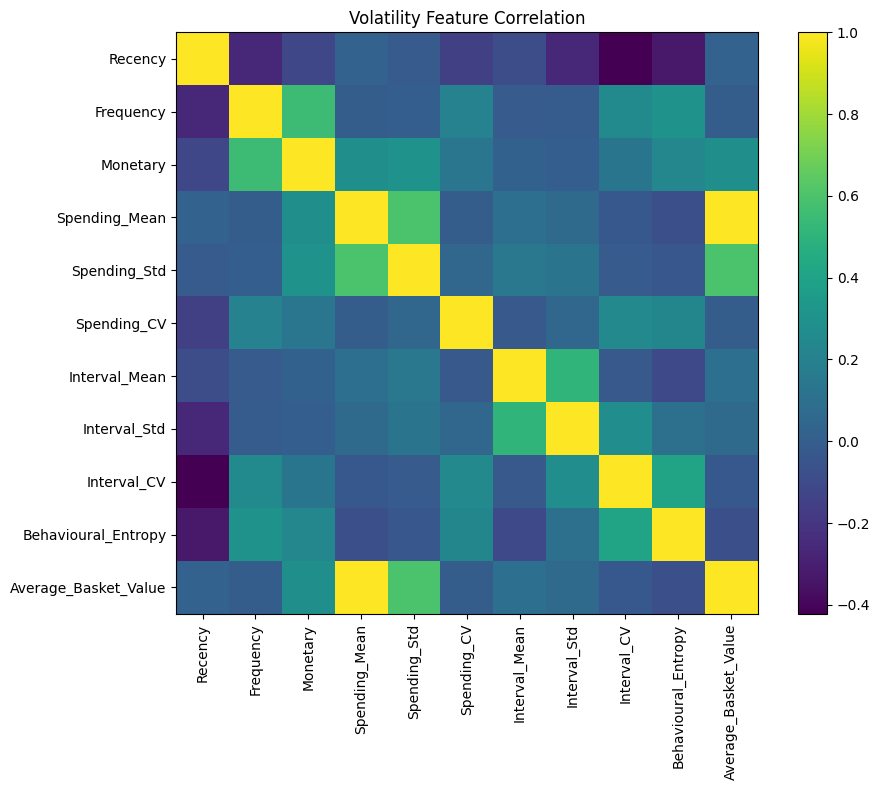

In [9]:
corr = rfm_vol.drop(columns=["CustomerID"]).corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(

    range(len(corr.columns)),

    corr.columns,

    rotation=90

)

plt.yticks(

    range(len(corr.columns)),

    corr.columns

)

plt.title("Volatility Feature Correlation")

plt.tight_layout()

plt.savefig(

    FIGURES_DIR /

    "volatility_correlation_heatmap.png",

    dpi=300

)

plt.show()

FEATURE DISTRIBUTION

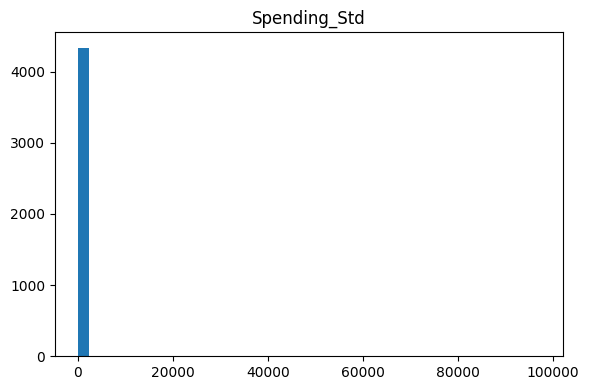

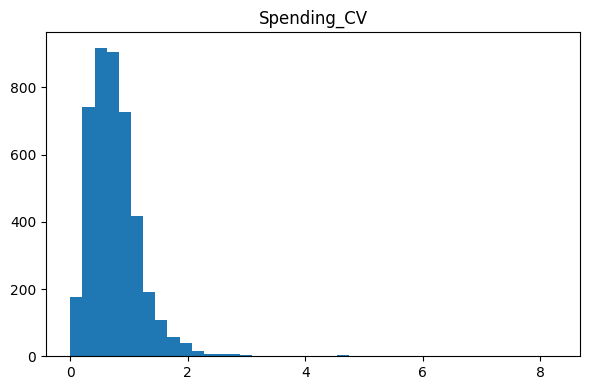

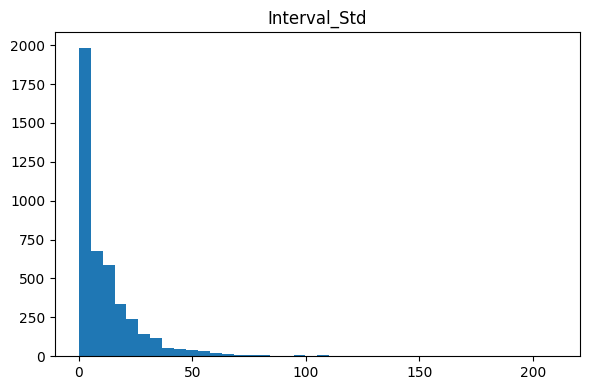

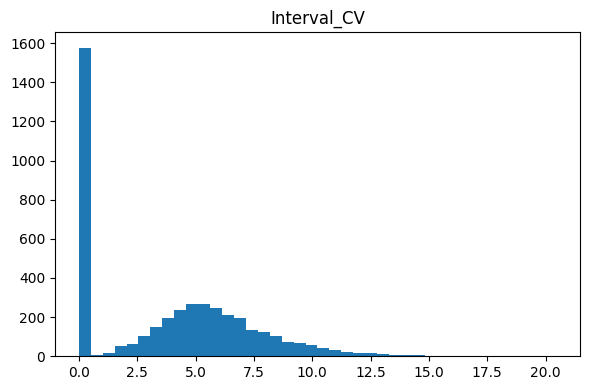

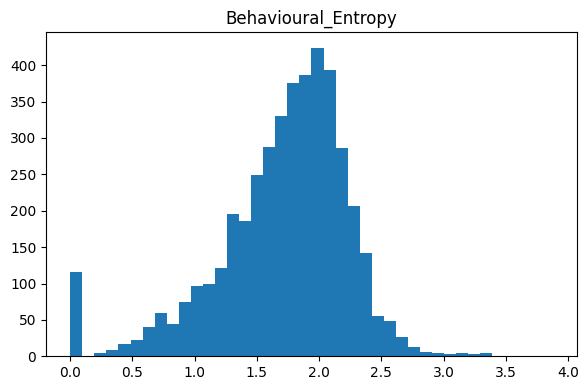

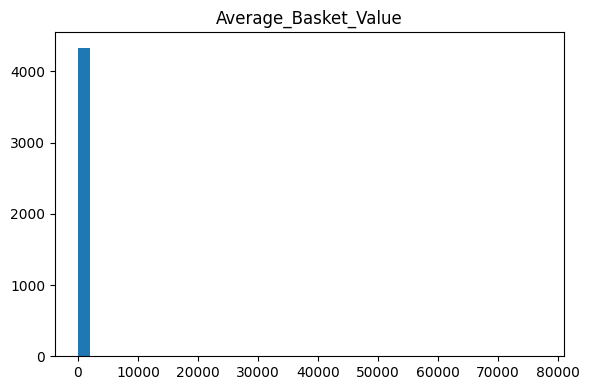

In [10]:
features = [

    "Spending_Std",

    "Spending_CV",

    "Interval_Std",

    "Interval_CV",

    "Behavioural_Entropy",

    "Average_Basket_Value"

]

for feature in features:

    plt.figure(figsize=(6,4))

    plt.hist(

        rfm_vol[feature],

        bins=40

    )

    plt.title(feature)

    plt.tight_layout()

    plt.savefig(

        FIGURES_DIR /

        f"{feature}.png",

        dpi=300

    )

    plt.show()

SAVE DATASET

In [11]:
rfm_vol.to_csv(

    PROCESSED_DIR /

    "rfm_volatility_features.csv",

    index=False

)

print("Saved successfully.")

Saved successfully.


EXPLANATION

In [12]:
print("VOLATILITY FEATURE ENGINEERING COMPLETE")
print("---------------------------------------")

print("Original Features : 3")

print("New Features Added : 7")

print("Total Features :",rfm_vol.shape[1]-1)

print()

print("Novel Features")

print("- Spending Std")

print("- Spending CV")

print("- Interval Mean")

print("- Interval Std")

print("- Interval CV")

print("- Behavioural Entropy")

print("- Average Basket Value")

VOLATILITY FEATURE ENGINEERING COMPLETE
---------------------------------------
Original Features : 3
New Features Added : 7
Total Features : 11

Novel Features
- Spending Std
- Spending CV
- Interval Mean
- Interval Std
- Interval CV
- Behavioural Entropy
- Average Basket Value


In [13]:
# ==========================================================
# PURCHASE FREQUENCY DISTRIBUTION
# ==========================================================

purchase_counts = (
    df.groupby("CustomerID")
      .size()
      .rename("Transactions")
)

summary = pd.DataFrame({
    "Customer Segment": [
        "1 Purchase",
        "2 Purchases",
        "3-5 Purchases",
        "More than 5 Purchases"
    ],
    "Customers": [
        (purchase_counts == 1).sum(),
        (purchase_counts == 2).sum(),
        ((purchase_counts >= 3) & (purchase_counts <= 5)).sum(),
        (purchase_counts > 5).sum()
    ]
})

summary["Percentage"] = (
    summary["Customers"] /
    summary["Customers"].sum() * 100
).round(2)

display(summary)

,Customer Segment,Customers,Percentage
0,1 Purchase,71,1.64
1,2 Purchases,54,1.24
2,3-5 Purchases,174,4.01
3,More than 5 Purchases,4039,93.11


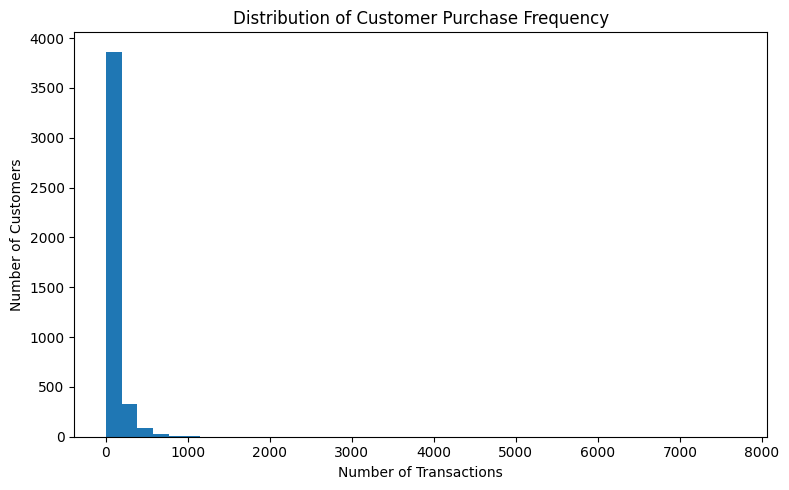

: 

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    purchase_counts,
    bins=40
)

plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Purchase Frequency")

plt.tight_layout()
plt.show()